<a href="https://colab.research.google.com/github/Plumz17/FinalProjectML/blob/main/FinalProjectML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Machine Learning Final Project - Depression Existence Prediction Model
Description: In this project, we build a machine learning model to predict the existence of depression among students based on various academic, lifestyle, and psychological factors.
The dataset used is the **Student Depression Dataset** sourced from Kaggle in the following link: https://www.kaggle.com/datasets/hopesb/student-depression-dataset,
which contains responses from students regarding their mental health status.
This project was made by Group 6:
*   Anders Emmanuel Tan (24/541351/PA/22964)
*   Dhimas Early Oceandy (24/533508/PA/22584)
*   Azhar Maulana (24/533487/PA/22582)
*   Evan Razzan Adytaputra (24/545257/PA/23166)



## 0. Setting Up
Description: For this first section, we will be preparing the data that will later be processed. Since the uploaded files in Google Colab are only available in the runtime, I will be attaining those files by cloning them from the Github Repository. Additionaly, we will also be importing the libaries that we will be using for this submission to process the images.

In [ ]:
# Cloning Github Repository to get the data files
!rm -rf FinalProjectML
!git clone https://github.com/Plumz17/FinalProjectML

Cloning into 'FinalProjectML'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 13 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 441.91 KiB | 2.48 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [ ]:
# Import Important Libraries
import numpy as np
import pandas as pd

# Import Data Frame
df = pd.read_csv('FinalProjectML/Student Depression Dataset.csv')

df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


## 1. Data Preparation
Description: For this first section, we will be preparing the data that will later be processed. Since the uploaded files in Google Colab are only available in the runtime, I will be attaining those files by cloning them from the Github Repository. Additionaly, we will also be importing the libaries that we will be using for this submission to process the images.

In [ ]:
# Data Exploration
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


In [ ]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [ ]:
# Check for NaN values
df[df.isna().any(axis=1)]

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
4458,22377,Female,32.0,Varanasi,Student,3.0,0.0,5.64,1.0,0.0,5-6 hours,Healthy,BCA,No,12.0,NaN,No,1
13596,68910,Male,29.0,Hyderabad,Student,2.0,0.0,8.94,3.0,0.0,Less than 5 hours,Unhealthy,B.Ed,No,12.0,NaN,Yes,0
19266,97610,Female,20.0,Kolkata,Student,1.0,0.0,6.83,1.0,0.0,5-6 hours,Healthy,MBBS,No,9.0,NaN,Yes,0


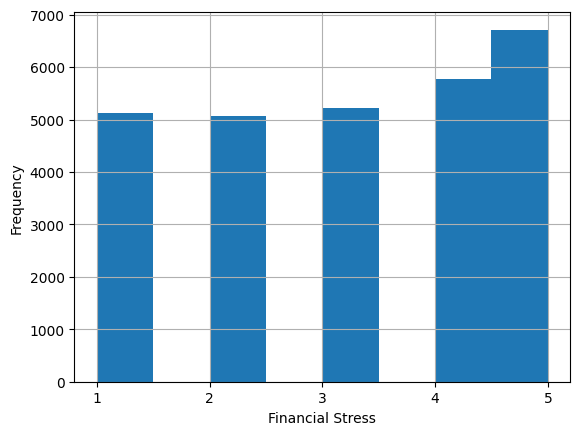

In [ ]:
import matplotlib.pyplot as plt

df["Financial Stress"].hist(bins=8)
plt.xlabel("Financial Stress")
plt.ylabel("Frequency")
plt.xticks(range(1, 6))
plt.show()

In [ ]:
# Check suspicous columns
print(df['Work Pressure'].value_counts())
print(df['Job Satisfaction'].value_counts())
print(df['Profession'].value_counts())

Work Pressure
0.0    27898
5.0        2
2.0        1
Name: count, dtype: int64
Job Satisfaction
0.0    27893
2.0        3
4.0        2
1.0        2
3.0        1
Name: count, dtype: int64
Profession
Student                   27870
Architect                     8
Teacher                       6
Digital Marketer              3
Chef                          2
Content Writer                2
Pharmacist                    2
Doctor                        2
UX/UI Designer                1
Civil Engineer                1
Manager                       1
Educational Consultant        1
Lawyer                        1
Entrepreneur                  1
Name: count, dtype: int64


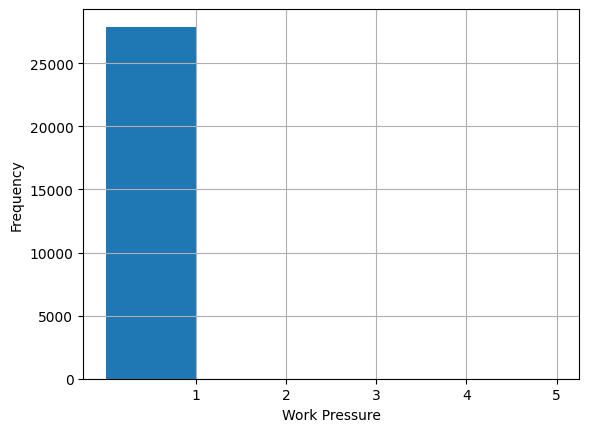

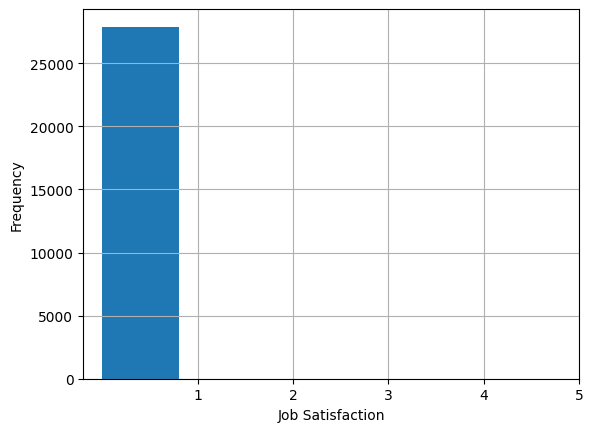

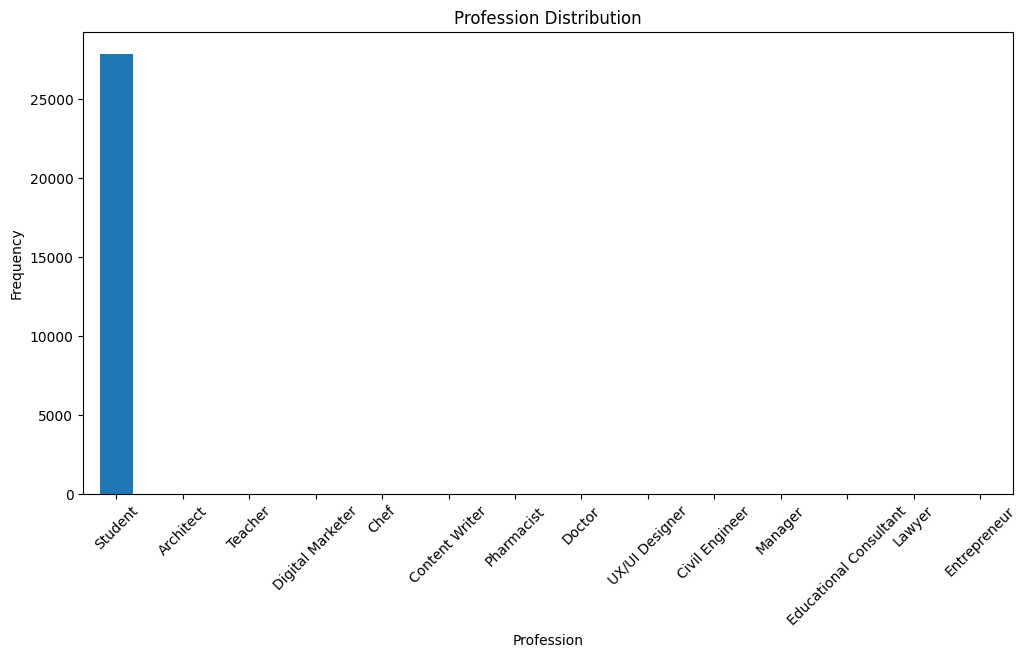

In [ ]:
df["Work Pressure"].hist(bins=5)
plt.xlabel("Work Pressure")
plt.ylabel("Frequency")
plt.xticks(range(1, 6))
plt.show()

df["Job Satisfaction"].hist(bins=5)
plt.xlabel("Job Satisfaction")
plt.ylabel("Frequency")
plt.xticks(range(1, 6))
plt.show()

plt.figure(figsize=(12, 6))
profession_counts = df["Profession"].value_counts()
profession_counts.plot(kind='bar')
plt.xlabel("Profession")
plt.ylabel("Frequency")
plt.title("Profession Distribution")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Fill NaN values with median
df = df.fillna(df.median(numeric_only=True))
df[df.isna().any(axis=1)]

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression


In [ ]:
# Drop irrelevant Columnns
df.drop(columns=['id', 'City', 'Profession', 'Work Pressure', "Job Satisfaction"], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 13 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27901 non-null  object 
 1   Age                                    27901 non-null  float64
 2   Academic Pressure                      27901 non-null  float64
 3   CGPA                                   27901 non-null  float64
 4   Study Satisfaction                     27901 non-null  float64
 5   Sleep Duration                         27901 non-null  object 
 6   Dietary Habits                         27901 non-null  object 
 7   Degree                                 27901 non-null  object 
 8   Have you ever had suicidal thoughts ?  27901 non-null  object 
 9   Work/Study Hours                       27901 non-null  float64
 10  Financial Stress                       27901 non-null  float64
 11  Fa

In [ ]:
# Binary Columns Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

binary_cols = [
  'Gender',
  'Have you ever had suicidal thoughts ?',
  'Family History of Mental Illness'
]

for col in binary_cols:
  df[col] = le.fit_transform(df[col])

df[binary_cols].head()

,Gender,Have you ever had suicidal thoughts ?,Family History of Mental Illness
0,1,1,0
1,0,0,1
2,1,0,1
3,0,1,1
4,0,1,0


In [ ]:
# Ordinal Columns Label Encoding
sleep_map = {
  'Less than 5 hours': 0,
  '5-6 hours': 1,
  '7-8 hours': 2,
  'More than 8 hours': 3,
  'Others': 3 # merge with the fewest category
}
diet_map = {
  'Unhealthy': 0,
  'Moderate': 1,
  'Healthy': 2,
  'Others': 2 # merge with the fewest category
}
df['Sleep Duration'] = df['Sleep Duration'].map(sleep_map)
df['Dietary Habits'] = df['Dietary Habits'].map(diet_map)
df[['Sleep Duration', 'Dietary Habits']].head()


,Sleep Duration,Dietary Habits
0,1,2
1,1,1
2,0,2
3,2,1
4,1,1


In [ ]:
# Nominal Columns Label Encoding using One Hot Encoder
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe = OneHotEncoder(sparse_output=False, drop='first')
degree_encoded = ohe.fit_transform(df[['Degree']])
degree_cols = ohe.get_feature_names_out(['Degree'])
degree_df = pd.DataFrame(degree_encoded, columns=degree_cols, index=df.index)
df = pd.concat([df.drop(columns=['Degree']), degree_df], axis=1)

# Verify results
df.filter(like='Degree').head()


,Degree_B.Com,Degree_B.Ed,Degree_B.Pharm,Degree_B.Tech,Degree_BA,Degree_BBA,Degree_BCA,Degree_BE,Degree_BHM,Degree_BSc,...,Degree_MA,Degree_MBA,Degree_MBBS,Degree_MCA,Degree_MD,Degree_ME,Degree_MHM,Degree_MSc,Degree_Others,Degree_PhD
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#2. Cross validation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
  accuracy_score,
  precision_score,
  recall_score,
  f1_score,
  classification_report
)

X = df.drop(columns=["Depression"])
y = df["Depression"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

models = {
  "Logistic Regression": Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
  ]),

  "Naive Bayes": Pipeline([
    ("scaler", StandardScaler()),
    ("model", GaussianNB())
  ]),

  "kNN": Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
  ]),
  "SVM": Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel='rbf', random_state=42))
  ]),
  "Decision Tree": Pipeline([
    ("model", DecisionTreeClassifier(random_state=42))
  ]),
  "Random Forest": Pipeline([
    ("model", RandomForestClassifier(
      n_estimators=100,
      random_state=42
    ))
  ]),
  "XGBoost": Pipeline([
    ("model", XGBClassifier(
      eval_metric='logloss',
      random_state=42
    ))
  ])
}
for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1'
    )

    print(name)
    print("Scores:", scores)
    print("Mean:", scores.mean())

Logistic Regression
Scores: [0.88       0.8673936  0.86743567 0.87662917 0.87004056]
Mean: 0.8722997997629266
Naive Bayes
Scores: [0.80810313 0.79079799 0.78342396 0.79275654 0.78490704]
Mean: 0.7919977314279534
kNN
Scores: [0.85107124 0.84166811 0.84161167 0.84833625 0.84560735]
Mean: 0.8456589241203204
SVM
Scores: [0.87814313 0.8645523  0.86496995 0.87364877 0.86993154]
Mean: 0.8702491406000847
Decision Tree
Scores: [0.80949811 0.80769231 0.80101486 0.80277829 0.80823402]
Mean: 0.8058435168654172
Random Forest
Scores: [0.87835926 0.85830677 0.86578854 0.87145659 0.86743567]
Mean: 0.8682693649485664
XGBoost
Scores: [0.87187666 0.86157644 0.86430731 0.86760765 0.86628734]
Mean: 0.8663310798171677


## 3. Hyperparameter tuning
Description: For this section, we will be training the machine learning models using the data that we have prepared in the previous section. As for the models, we will compare the performance of several different machine learning models to determine which one yields the best result. The following are the models that we use: Logistic Regression, Naive Bayes, kNN, SVM, Decision Tree, Random Forest, and XGBoost.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)
model_tuned = grid.best_estimator_

print(grid.best_params_)
print(grid.best_score_)

{'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
0.8728597759269199


## 4. Evaluation
Description:

In [ ]:
#use tuned model on test set
y_pred = model_tuned.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(classification_report(y_test, y_pred))

Accuracy : 0.8435
Precision: 0.8508
Recall   : 0.8886
F1-Score : 0.8693
              precision    recall  f1-score   support

           0       0.83      0.78      0.81      1735
           1       0.85      0.89      0.87      2451

    accuracy                           0.84      4186
   macro avg       0.84      0.83      0.84      4186
weighted avg       0.84      0.84      0.84      4186



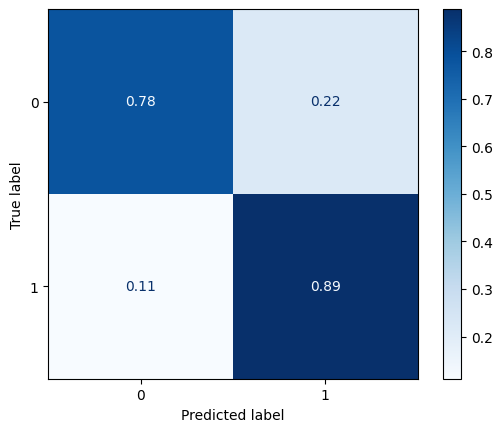

In [ ]:
#confusion matrix on test set
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_estimator(
    model_tuned, X_test, y_test, cmap=plt.cm.Blues,
    normalize='true'
)
plt.show()

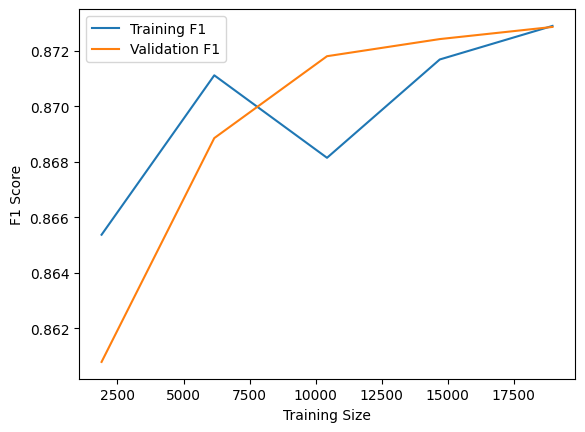

In [ ]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

#tuned model learning curve
train_sizes, train_scores, val_scores = learning_curve(
    model_tuned, X_train, y_train,
    cv=5, scoring="f1"
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.plot(train_sizes, train_mean, label='Training F1')
plt.plot(train_sizes, val_mean, label='Validation F1')

plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.legend()
plt.show()

## 5. Entering a new data
Description:

In [ ]:
print("Enter student data for prediction!")
gender = input("Gender (Male/Female): ").strip()
age = float(input("Age: "))
academic_pressure = float(input("Academic Pressure (1-5): "))
cgpa = float(input("GPA (0-4): ")) * 2.5
study_satisfaction = float(input("Study Satisfaction (1-5): "))
sleep_raw = input("Sleep Duration (Less than 5 hours / 5-6 hours / 7-8 hours / More than 8 hours): ").strip()
diet_raw = input("Dietary Habits (Unhealthy / Moderate / Healthy): ").strip()
suicidal = input("Ever had suicidal thoughts? (Yes/No): ").strip()
study_hours = float(input("Study Hours per day: "))
financial_stress = float(input("Financial Stress (1-5): "))
family_history = input("Family History of Mental Illness (Yes/No): ").strip()
degree_raw = input("Degree (e.g. B.Tech, M.Tech, BSc, MBA, etc.): ").strip()

#Encode Input (Pre-processing)
gender_enc = 1 if gender.lower() == "male" else 0
suicidal_enc = 1 if suicidal.lower() == "yes" else 0
family_enc = 1 if family_history.lower() == "yes" else 0

sleep_map_input = {"less than 5 hours": 0, "5-6 hours": 1, "7-8 hours": 2, "more than 8 hours": 3}
sleep_enc = sleep_map_input.get(sleep_raw.lower(), 2)

diet_map_input = {"unhealthy": 0, "moderate": 1, "healthy": 2}
diet_enc = diet_map_input.get(diet_raw.lower(), 1)

degree_input = pd.DataFrame([[degree_raw]], columns=["Degree"])
if degree_raw in ohe.categories_[0]:
  degree_encoded_input = ohe.transform(degree_input)
else:
  degree_encoded_input = [[0] * len(ohe.get_feature_names_out())]
degree_df_input = pd.DataFrame(degree_encoded_input, columns=ohe.get_feature_names_out(["Degree"]))

# Build the row
base = pd.DataFrame([[
  gender_enc, age, academic_pressure, cgpa, study_satisfaction,
  sleep_enc, diet_enc, suicidal_enc, study_hours, financial_stress, family_enc
]], columns=[
  "Gender", "Age", "Academic Pressure", "CGPA", "Study Satisfaction",
  "Sleep Duration", "Dietary Habits",
  "Have you ever had suicidal thoughts ?", "Study Hours",
  "Financial Stress", "Family History of Mental Illness"
])
new_row = pd.concat([base, degree_df_input], axis=1)

# Align columns with training data
new_row = new_row.reindex(columns=X_train.columns, fill_value=0)


# Predict
prob = model_tuned.predict_proba(X_test)
prediction = model_tuned.predict(new_row)[0]
conf = np.max(prob)
result = "Depressed" if prediction == 1 else "Not Depressed"
print(f"\nPrediction: {result}")
print(f"Confidence: {conf}")

Enter student data for prediction!


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_4815/705582009.py", line 2, in <cell line: 0>
    gender = input("Gender (Male/Female): ").strip()
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py", line 1177, in raw_input
    return self._input_request(
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py", line 1219, in _input_request
    raise KeyboardInterrupt("Interrupted by user") from None
KeyboardInterrupt: Interrupted by user

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 2099, in showtraceback
    stb = value._render_traceback_()
          ^^^^^^^^^^

TypeError: object of type 'NoneType' has no len()